<a href="https://colab.research.google.com/github/akwve/STA160_Group2_Project/blob/main/STA_160_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets torch scikit-learn


In [ ]:
!pip uninstall -y transformers tokenizers accelerate datasets pyarrow
!pip install -U "transformers>=4.40" "datasets>=2.19" "accelerate>=0.30" evaluate "pyarrow>=14,<20"




Found existing installation: transformers 4.57.1
Uninstalling transformers-4.57.1:
  Successfully uninstalled transformers-4.57.1
Found existing installation: tokenizers 0.22.1
Uninstalling tokenizers-0.22.1:
  Successfully uninstalled tokenizers-0.22.1
Found existing installation: accelerate 1.11.0
Uninstalling accelerate-1.11.0:
  Successfully uninstalled accelerate-1.11.0
Found existing installation: datasets 4.3.0
Uninstalling datasets-4.3.0:
  Successfully uninstalled datasets-4.3.0
Found existing installation: pyarrow 22.0.0
Uninstalling pyarrow-22.0.0:
  Successfully uninstalled pyarrow-22.0.0
  Using cached transformers-4.57.1-py3-none-any.whl.metadata (43 kB)
  Using cached datasets-4.3.0-py3-none-any.whl.metadata (18 kB)
  Using cached accelerate-1.11.0-py3-none-any.whl.metadata (19 kB)
  Using cached tokenizers-0.22.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
INFO: pip is looking at multiple versions of datasets to determine which version is 

In [2]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Adjusted_Combined_Truth_Features.csv")
print(df.head())
print(df.columns)


Saving Adjusted_Combined_Truth_Features.csv to Adjusted_Combined_Truth_Features.csv
   Unnamed: 0      author                                        statement_x  \
0           0  D.L. Davis  End of eviction moratorium means millions of A...   
1           1  D.L. Davis  End of eviction moratorium means millions of A...   
2           2  D.L. Davis  End of eviction moratorium means millions of A...   
3           3  D.L. Davis  End of eviction moratorium means millions of A...   
4           4  D.L. Davis  End of eviction moratorium means millions of A...   

   target  BinaryNumTarget_x                 manual_keywords  \
0    True                  1  Americans, eviction moratorium   
1    True                  1  Americans, eviction moratorium   
2    True                  1  Americans, eviction moratorium   
3    True                  1  Americans, eviction moratorium   
4    True                  1  Americans, eviction moratorium   

                                             tweet

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv("Adjusted_Combined_Truth_Features.csv")

# 1) Clean text & pick label
text_col = "tweet_x"
if "BinaryNumTarget_x" in df.columns:
    y = df["BinaryNumTarget_x"].astype(int)
else:
    # Fall back to 'target' as True/False → 1/0
    y = df["target"].astype(str).str.lower().map({"true":1, "false":0}).astype(int)

X = df[text_col].astype(str).fillna("")

# 2) Optional: sanity check class balance
print("Class balance (0=fake,1=real):")
print(y.value_counts(normalize=True).round(3))

# 3) Split (stratified)
y = 1 - df["BinaryNumTarget_x"].astype(int)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
len(X_train), len(X_val)


Class balance (0=fake,1=real):
BinaryNumTarget_x
1    0.514
0    0.486
Name: proportion, dtype: float64


(107358, 26840)

In [4]:
from transformers import BertTokenizerFast

model_name = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(model_name)

max_len = 384
enc_train = tokenizer(list(X_train), truncation=True, padding=True, max_length=max_len)
enc_val   = tokenizer(list(X_val),   truncation=True, padding=True, max_length=max_len)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [5]:
import torch

class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = np.array(labels, dtype=np.int64)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_ds = NewsDataset(enc_train, y_train.values)
val_ds   = NewsDataset(enc_val,   y_val.values)


In [6]:
from transformers import BertForSequenceClassification

num_labels = 2  # 0=fake, 1=real
model = BertForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = logits if isinstance(logits, np.ndarray) else logits[0]
    preds = probs.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    # For AUC we need probabilities for class 1
    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except Exception:
        auc = float("nan")

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}


In [8]:
###PREFLIGHT CHECKLIST
# 1) Versions / args support
import transformers, torch, inspect
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("Trainer has 'processing_class'?", "processing_class" in inspect.signature(transformers.Trainer.__init__).parameters)

# 2) Required objects exist
for name in ["tokenizer","model","train_ds","val_ds","compute_metrics"]:
    assert name in globals(), f"Missing: {name}"

# 3) Dataset sanity
assert len(train_ds) > 0 and len(val_ds) > 0, "Empty dataset"
sample = train_ds[0]
for k in ["input_ids","attention_mask","labels"]:
    assert k in sample, f"Missing key {k} in dataset item"
assert sample["labels"].dtype in (torch.int64, torch.long), "labels must be int64/long"

# 4) Class balance (sanity)
import numpy as np
def _labels(ds, n=2000):
    import itertools
    idx = range(min(n, len(ds)))
    return np.array([ds[i]["labels"] for i in idx])
y_tr_small = _labels(train_ds)
y_va_small = _labels(val_ds)
print("train label mean:", y_tr_small.mean(), " counts:", np.bincount(y_tr_small))
print("val   label mean:", y_va_small.mean(),   " counts:", np.bincount(y_va_small))

# 5) Device / speed knobs
print("CUDA available?", torch.cuda.is_available())
if torch.cuda.is_available():
    torch.cuda.empty_cache()


transformers: 4.57.1
torch: 2.8.0+cu126
Trainer has 'processing_class'? True
train label mean: 0.4835  counts: [1033  967]
val   label mean: 0.4925  counts: [1015  985]
CUDA available? True


In [9]:
# --- Silence W&B auto-login ---
import os
os.environ["WANDB_DISABLED"] = "true"   # disables wandb completely

from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import inspect


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Your existing args, with report_to="none" to be extra sure
training_args = TrainingArguments(
    output_dir="./bert_fake_news",
    do_train=True,
    do_eval=True,
    logging_steps=100,
    save_steps=500,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,  # ✅ enables mixed-precision (safe on T4)
    seed=42,
    report_to="none",
)


# --- Backward/forward compatible Trainer init ---
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Prefer the modern arg if this version supports it; else fall back.
if "processing_class" in inspect.signature(Trainer.__init__).parameters:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer  # older versions expect this

trainer = Trainer(**trainer_kwargs)

trainer.train()
eval_metrics = trainer.evaluate()
print(eval_metrics)


Step,Training Loss
100,0.548700
200,0.369500
300,0.318300
400,0.288300
500,0.213800
600,0.251100
700,0.195200
800,0.165000
900,0.175000
1000,0.144100


{'eval_loss': 0.037419643253088, 'eval_accuracy': 0.9939642324888227, 'eval_precision': 0.9947045280122794, 'eval_recall': 0.9928757468975027, 'eval_f1': 0.9937892961202269, 'eval_auc': 0.9997111508443395, 'eval_runtime': 141.3211, 'eval_samples_per_second': 189.922, 'eval_steps_per_second': 11.874, 'epoch': 3.0}


In [10]:
# --- Save model and tokenizer ---
model.save_pretrained("/content/bert_fake_news_model")
tokenizer.save_pretrained("/content/bert_fake_news_model")
from google.colab import files
!zip -r bert_fake_news_model.zip /content/bert_fake_news_model
files.download("bert_fake_news_model.zip")


  adding: content/bert_fake_news_model/ (stored 0%)
  adding: content/bert_fake_news_model/vocab.txt (deflated 53%)
  adding: content/bert_fake_news_model/special_tokens_map.json (deflated 42%)
  adding: content/bert_fake_news_model/model.safetensors (deflated 7%)
  adding: content/bert_fake_news_model/tokenizer.json (deflated 71%)
  adding: content/bert_fake_news_model/tokenizer_config.json (deflated 75%)
  adding: content/bert_fake_news_model/config.json (deflated 49%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/bert_fake_news_model"
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)


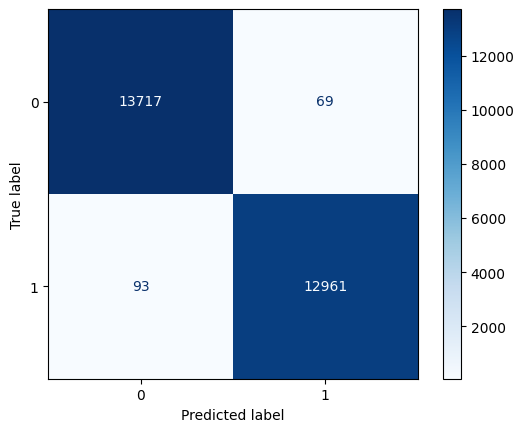

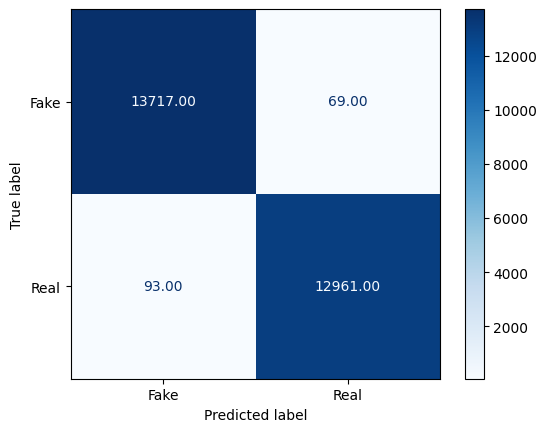

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
preds_output = trainer.predict(val_ds)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot(cmap="Blues", values_format=".2f")

In [17]:
from google.colab import drive
drive.mount("/content/drive")
!unzip "/content/drive/MyDrive/bert_fake_news_model.zip" -d /content/bert_fake_news_model
from transformers import AutoTokenizer, AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained("/content/bert_fake_news_model")
tokenizer = AutoTokenizer.from_pretrained("/content/bert_fake_news_model")


Mounted at /content/drive
unzip:  cannot find or open /content/drive/MyDrive/bert_fake_news_model.zip, /content/drive/MyDrive/bert_fake_news_model.zip.zip or /content/drive/MyDrive/bert_fake_news_model.zip.ZIP.


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("./bert_fake_news")
tokenizer = AutoTokenizer.from_pretrained("./bert_fake_news")


OSError: Error no file named pytorch_model.bin, model.safetensors, tf_model.h5, model.ckpt.index or flax_model.msgpack found in directory ./bert_fake_news.

In [ ]:
.....


In [ ]:
# Ensure labels are in the config (edit names if needed)
model.config.id2label = {0: "Fake", 1: "Real"}
model.config.label2id = {"Fake": 0, "Real": 1}

save_dir = "/content/bert_final"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
!zip -r /content/bert_final.zip /content/bert_final
from google.colab import files
files.download("/content/bert_final.zip")


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, numpy as np

# --- 1. Load your model (change to your path or Hugging Face repo name) ---
MODEL_PATH = "/content/bert_final"  # or "your-username/bert-fake-news"

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
id2label = model.config.id2label or {0: "LABEL_0", 1: "LABEL_1"}

# --- 2. Define a quick classify function ---
def classify_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)[0].cpu().numpy()
    pred = np.argmax(probs)
    label = id2label.get(int(pred), str(pred))
    return label, probs

# --- 3. Prompt the user for input and display prediction ---
text = input("Enter text to analyze:\n\n")
label, probs = classify_text(text)

print("\nPredicted label:", label)
for i, p in enumerate(probs):
    print(f"{id2label.get(i, i)}: {p:.3f}")
